# 📘 Penerapan Deep Learning untuk Analisis Sentimen Ulasan Pelanggan pada    Platform E-Commerce

# **🧩 1. Import Library**
## ✍️ Penjelasan

### Pada tahap ini dilakukan proses impor seluruh library yang dibutuhkan untuk pengolahan data, pemodelan, serta evaluasi hasil. Library seperti NumPy dan Pandas digunakan untuk manipulasi data numerik dan tabular. Matplotlib dan Seaborn digunakan untuk visualisasi hasil pelatihan model. Library dari Scikit-learn dimanfaatkan untuk proses pembagian data, encoding label, serta evaluasi model. Sementara itu, TensorFlow/Keras digunakan sebagai framework utama dalam membangun dan melatih model deep learning berbasis LSTM. Tahap ini penting karena seluruh proses selanjutnya bergantung pada ketersediaan library yang sesuai.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout


# **🗂️ 2. Mount Google Drive**
## **✍️ Penjelasan**

### Dataset yang digunakan dalam penelitian ini disimpan di Google Drive. Oleh karena itu, perlu dilakukan proses mounting agar Google Colab dapat mengakses file yang ada di Drive. Dengan melakukan mount, direktori Drive akan terhubung langsung ke lingkungan kerja Colab, sehingga file dapat dibaca seperti file lokal. Tahap ini penting untuk memastikan data dapat diakses secara konsisten tanpa perlu mengunggah ulang setiap kali notebook dijalankan.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **📊 3. Load Dataset dari Drive**
## **✍️ Penjelasan**

### Setelah Drive terhubung, dataset dibaca menggunakan fungsi read_csv() dari Pandas. Dataset ini berisi ulasan pelanggan Tokopedia beserta rating produk. Pada tahap ini juga dilakukan pengecekan awal terhadap struktur data menggunakan head(), info(), dan columns() untuk memastikan kolom yang dibutuhkan tersedia, khususnya kolom text sebagai ulasan dan rating sebagai dasar pelabelan sentimen.

In [6]:
file_path = "/content/drive/MyDrive/Colab Notebooks/tokopedia-product-reviews-2019.csv"
df = pd.read_csv(file_path)

df.head()



,Unnamed: 0,text,rating,category,product_name,product_id,sold,shop_id,product_url
0,1,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - S...,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staple...
1,2,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...
2,3,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...
3,4,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; O...,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-stap...
4,5,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gu...,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-ref...


# **🧹 4. Seleksi Kolom dan Pembersihan Data**
## **✍️ Penjelasan**
### Dataset asli memiliki beberapa kolom yang tidak seluruhnya relevan untuk analisis sentimen. Oleh karena itu, pada tahap ini hanya dipilih dua kolom utama, yaitu text dan rating. Selanjutnya dilakukan penghapusan data yang memiliki nilai kosong (null) untuk mencegah error saat proses pelatihan model. Pembersihan ini bertujuan agar model hanya dilatih menggunakan data yang valid dan lengkap

In [7]:
df = df[['text', 'rating']]
df = df.dropna()
df.shape


(40607, 2)

# **🏷️ 5. Pelabelan Sentimen Berdasarkan Rating**
## **✍️ Penjelasan**

### Karena dataset tidak menyediakan label sentimen secara eksplisit, maka dilakukan proses pelabelan otomatis berdasarkan nilai rating. Rating 4 dan 5 dianggap sebagai sentimen positif, rating 1 dan 2 sebagai negatif, sedangkan rating 3 dianggap netral dan tidak digunakan dalam penelitian ini. Pendekatan ini umum digunakan dalam analisis sentimen berbasis ulasan karena rating merepresentasikan kepuasan pelanggan terhadap produk.

In [8]:
def label_sentiment(r):
    if r >= 4:
        return 'positif'
    elif r <= 2:
        return 'negatif'
    else:
        return 'netral'

df['sentiment'] = df['rating'].apply(label_sentiment)
df = df[df['sentiment'] != 'netral']
df['sentiment'].value_counts()


,count
sentiment,
positif,37857
negatif,925


# **🧹 6. Preprocessing Teks**
## **✍️ Penjelasan**

### Tahap preprocessing bertujuan untuk membersihkan teks ulasan agar lebih terstruktur dan mudah dipahami oleh model. Proses yang dilakukan meliputi mengubah teks menjadi huruf kecil (lowercase), menghapus URL, angka, tanda baca, serta spasi berlebih. Pembersihan ini penting karena noise pada teks dapat menurunkan performa model deep learning dalam menangkap pola sentimen.

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)
df[['text','text_clean']].head()


,text,text_clean
0,Barang sesuai pesanan dan cepat sampai,barang sesuai pesanan dan cepat sampai
1,Barang bagus harga murah,barang bagus harga murah
2,Paket rapi...mantap....cepat....sampe ke tujuan,paket rapimantapcepatsampe ke tujuan
3,ya saya puas dgn barangnya,ya saya puas dgn barangnya
4,Responya luar biasa b mantap,responya luar biasa b mantap


# **🔢 7. Encoding Label**
## **✍️ Penjelasan**

### Model deep learning hanya dapat memproses data numerik, sehingga label sentimen berbentuk teks perlu diubah menjadi angka. Pada tahap ini digunakan LabelEncoder untuk mengonversi label “negatif” menjadi 0 dan “positif” menjadi 1. Proses ini mempermudah model dalam mempelajari hubungan antara fitur teks dan kelas sentimen.

In [10]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
df[['sentiment','label']].head()


,sentiment,label
0,positif,1
1,positif,1
2,positif,1
3,positif,1
4,positif,1


# **🔀 8. Pembagian Data Train dan Test**
## **✍️ Penjelasan**

### Dataset dibagi menjadi dua bagian, yaitu data latih (training) dan data uji (testing) dengan proporsi 80:20. Data latih digunakan untuk melatih model, sedangkan data uji digunakan untuk mengukur kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya. Pembagian dilakukan secara acak namun tetap menjaga proporsi kelas dengan parameter stratify.

In [11]:
X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# **🔠 9. Tokenisasi dan Padding**
## **✍️ Penjelasan**

### Pada tahap ini, teks diubah menjadi representasi numerik menggunakan proses tokenisasi. Setiap kata diubah menjadi indeks berdasarkan kamus yang dibentuk dari data latih. Selanjutnya dilakukan padding agar seluruh sequence memiliki panjang yang sama. Hal ini diperlukan karena model LSTM membutuhkan input dengan dimensi yang seragam.

In [12]:
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=max_len, padding='post')


# **🤖 10. Pembangunan Model LSTM**
## **✍️ Penjelasan**

### Model deep learning dibangun menggunakan arsitektur LSTM karena mampu menangkap dependensi jangka panjang pada data sekuensial seperti teks. Layer Embedding digunakan untuk mengubah indeks kata menjadi vektor berdimensi tetap. Layer LSTM bertugas mempelajari pola urutan kata, sedangkan Dropout digunakan untuk mengurangi overfitting. Layer Dense dengan aktivasi sigmoid menghasilkan output probabilitas untuk klasifikasi biner.

In [13]:
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(128),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **▶️ 11. Training Model**
## **✍️ Penjelasan**

### Pada tahap ini model dilatih menggunakan data latih selama beberapa epoch. Proses training bertujuan untuk menyesuaikan bobot model agar mampu meminimalkan nilai loss. Selain itu, data uji digunakan sebagai validation untuk memantau performa model pada setiap epoch sehingga dapat diketahui apakah model mengalami overfitting atau tidak.

In [14]:
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)


Epoch 1/5
485/485 ━━━━━━━━━━━━━━━━━━━━ 152s 308ms/step - accuracy: 0.9667 - loss: 0.1432 - val_accuracy: 0.9763 - val_loss: 0.1134
Epoch 2/5
485/485 ━━━━━━━━━━━━━━━━━━━━ 168s 239ms/step - accuracy: 0.9757 - loss: 0.1171 - val_accuracy: 0.9762 - val_loss: 0.1142
Epoch 3/5
485/485 ━━━━━━━━━━━━━━━━━━━━ 144s 243ms/step - accuracy: 0.9788 - loss: 0.1047 - val_accuracy: 0.9760 - val_loss: 0.1125
Epoch 4/5
485/485 ━━━━━━━━━━━━━━━━━━━━ 116s 239ms/step - accuracy: 0.9780 - loss: 0.1085 - val_accuracy: 0.9763 - val_loss: 0.1129
Epoch 5/5
485/485 ━━━━━━━━━━━━━━━━━━━━ 116s 239ms/step - accuracy: 0.9777 - loss: 0.1096 - val_accuracy: 0.9760 - val_loss: 0.1129


# **📈 12. Visualisasi Hasil Training**
## **✍️ Penjelasan**

### Grafik akurasi dan loss digunakan untuk menganalisis proses pembelajaran model. Dengan visualisasi ini, dapat diamati apakah model mengalami peningkatan performa seiring bertambahnya epoch dan apakah terdapat perbedaan signifikan antara data latih dan validasi. Grafik ini sangat penting sebagai bahan analisis pada laporan penelitian.

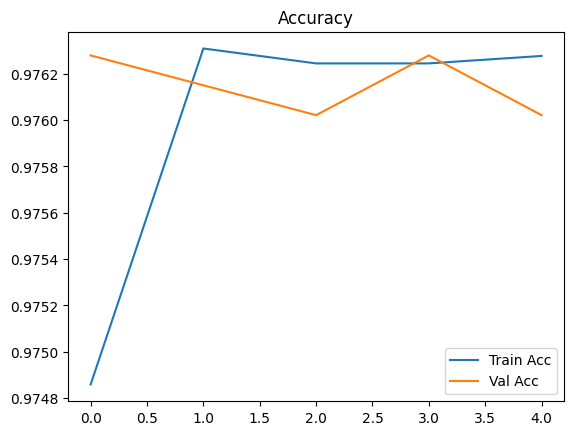

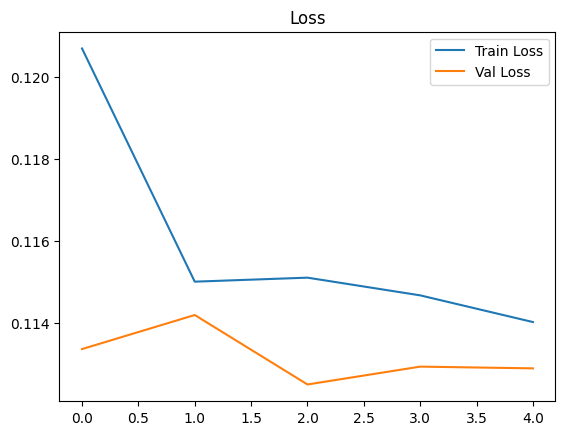

In [15]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy'); plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss'); plt.show()


# **🧪 13. Evaluasi Model**
## **✍️ Penjelasan**

### Evaluasi dilakukan menggunakan data uji untuk mengukur performa akhir model. Selain nilai akurasi, digunakan juga confusion matrix dan classification report untuk mengetahui nilai precision, recall, dan F1-score. Evaluasi ini memberikan gambaran seberapa baik model dalam mengklasifikasikan ulasan positif dan negatif.

243/243 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.9749 - loss: 0.1167
Loss   : 0.11289439350366592
Akurasi: 0.9760216474533081
243/243 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step


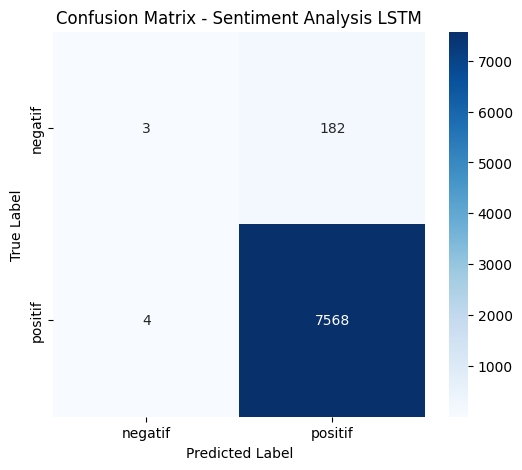


Classification Report:

              precision    recall  f1-score   support

     negatif       0.43      0.02      0.03       185
     positif       0.98      1.00      0.99      7572

    accuracy                           0.98      7757
   macro avg       0.70      0.51      0.51      7757
weighted avg       0.96      0.98      0.97      7757



In [20]:
# Evaluasi akurasi
loss, acc = model.evaluate(X_test_pad, y_test)
print("Loss   :", loss)
print("Akurasi:", acc)

# Prediksi data test
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Sentiment Analysis LSTM')
plt.show()

# Tetap tampilkan classification report (opsional tapi bagus untuk laporan)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


# **🔮 14. Uji Prediksi Manual**
## **✍️ Penjelasan**

### Tahap ini bertujuan untuk menguji model secara langsung menggunakan kalimat baru. Dengan fungsi ini, pengguna dapat memasukkan ulasan secara manual dan melihat hasil prediksi sentimen dari model. Ini menunjukkan bahwa model tidak hanya bekerja pada data uji, tetapi juga dapat diaplikasikan pada data nyata.

In [18]:
def predict_sentiment(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')
    pred = model.predict(pad)[0][0]
    return "positif" if pred > 0.5 else "negatif"

predict_sentiment("Pengiriman cepat dan produk sangat bagus")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


'positif'

# **💾 15. Penyimpanan Model**
## **✍️ Penjelasan**

### Model yang telah dilatih disimpan ke Google Drive agar dapat digunakan kembali tanpa perlu melakukan training ulang. Penyimpanan ini penting untuk keperluan deployment, pengujian lanjutan, atau dokumentasi hasil penelitian.

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/model_sentimen_tokopedia.h5')
